### Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

### Fungsi Untuk Down Sampling

In [2]:
def downsampling(image, factor, method='average'):
    h, w, c = image.shape
    new_h, new_w = h // factor, w // factor
    hasil = np.zeros((new_h, new_w, c), dtype=np.uint8)
    for i in range(new_h):
        for j in range(new_w):
            block = image[i*factor:(i+1)*factor, j*factor:(j+1)*factor]
            if method == 'max':
                hasil[i,j] = np.max(block, axis=(0,1))
            if method == 'average':
                hasil[i,j] = np.average(block, axis=(0,1))
            if method == 'medium':
                hasil[i,j] = np.median(block, axis=(0,1))
    return hasil


### NN function

In [3]:
def UpSamplingNN(image, scale):
    is_grayscale = False
    if image.ndim == 2:
        is_grayscale = True
        image = np.expand_dims(image, axis=-1)
        
    h, w, c = image.shape
    new_h, new_w = int(h * scale), int(w * scale)
    hasil = np.zeros((new_h, new_w, c), dtype=np.uint8)
    
    for i in range(new_h):
        for j in range(new_w):
            x = min(int(j / scale), w - 1)
            y = min(int(i / scale), h - 1)
            
            hasil[i,j] = image[y, x]
            
    if is_grayscale:
        hasil = np.squeeze(hasil, axis=-1)
        
    return hasil

### Bilinear Up Sampling

In [4]:
def UpSamplingBilinear(image, scale):
    is_grayscale = False
    if image.ndim == 2:
        is_grayscale = True
        image = np.expand_dims(image, axis=-1)
        
    img_float = image.astype(np.float64)
    h, w, c = image.shape
    new_h, new_w = int(h * scale), int(w * scale)
    
    hasil = np.zeros((new_h, new_w, c), dtype=np.float64)
    
    for i in range(new_h):
        y = i / scale
        y1 = int(y)
        y2 = min(y1 + 1, h - 1)
        dy = y - y1
        
        for j in range(new_w):
            x = j / scale
            x1 = int(x)
            x2 = min(x1 + 1, w - 1)
            dx = x - x1
            
            p1 = img_float[y1, x1]
            p2 = img_float[y1, x2]
            p3 = img_float[y2, x1]
            p4 = img_float[y2, x2]
            
            top = p1 * (1 - dx) + p2 * dx
            bottom = p3 * (1 - dx) + p4 * dx
            
            hasil[i, j] = top * (1 - dy) + bottom * dy
            
    hasil = np.clip(np.rint(hasil), 0, 255).astype(np.uint8)
    
    if is_grayscale:
        hasil = np.squeeze(hasil, axis=-1)
        
    return hasil

### Bicubic Up Sampling

In [5]:
def UpSamplingBicubic(image, scale):
    is_grayscale = False
    if image.ndim == 2:
        is_grayscale = True
        image = np.expand_dims(image, axis=-1)
        
    img_float = image.astype(np.float64)
    h, w, c = image.shape
    new_h, new_w = int(h * scale), int(w * scale)
    
    hasil = np.zeros((new_h, new_w, c), dtype=np.float64)
    def cubic_weight(x, a=-0.5):
        abs_x = abs(x)
        if abs_x <= 1:
            return (a + 2) * (abs_x**3) - (a + 3) * (abs_x**2) + 1
        elif 1 < abs_x < 2:
            return a * (abs_x**3) - 5 * a * (abs_x**2) + 8 * a * abs_x - 4 * a
        else:
            return 0

    for i in range(new_h):
        y = i / scale
        y_int = int(y)
        dy = y - y_int
        
        for j in range(new_w):
            x = j / scale
            x_int = int(x)
            dx = x - x_int
            
            pixel_val = np.zeros(c, dtype=np.float64)
            for m in range(-1, 3):
                for n in range(-1, 3):
                    
                    y_pos = min(max(y_int + m, 0), h - 1)
                    x_pos = min(max(x_int + n, 0), w - 1)
                    
                    bobot_x = cubic_weight(n - dx)
                    bobot_y = cubic_weight(m - dy)
                    
                    pixel_val += img_float[y_pos, x_pos] * bobot_x * bobot_y
            
            hasil[i, j] = pixel_val
            
    hasil = np.clip(np.rint(hasil), 0, 255).astype(np.uint8)
    
    if is_grayscale:
        hasil = np.squeeze(hasil, axis=-1)
        
    return hasil

## Import Images

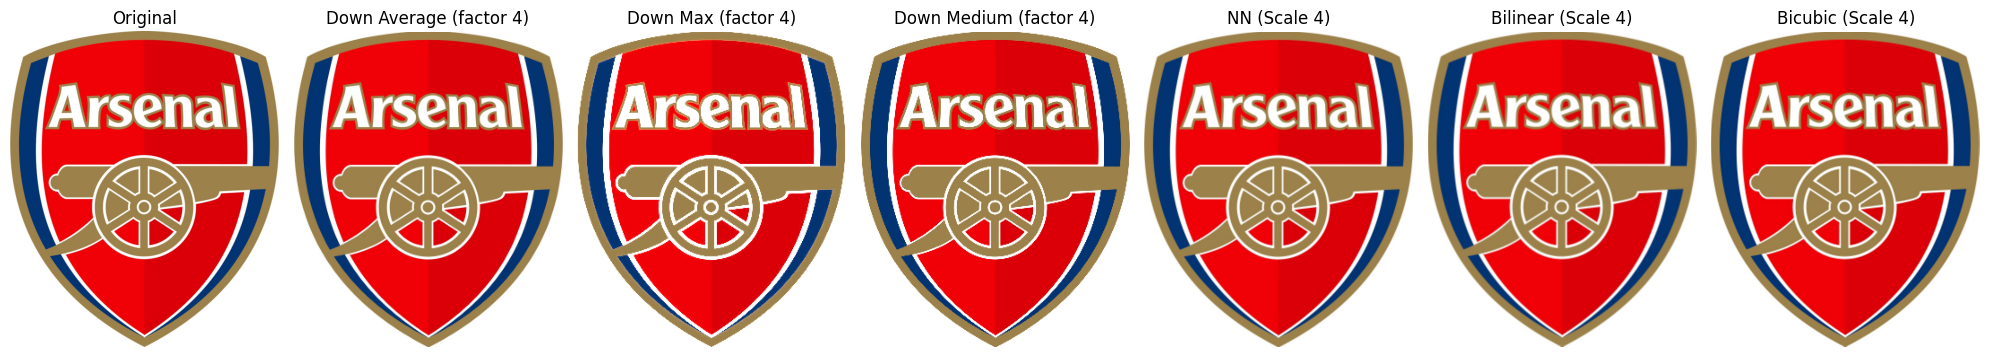

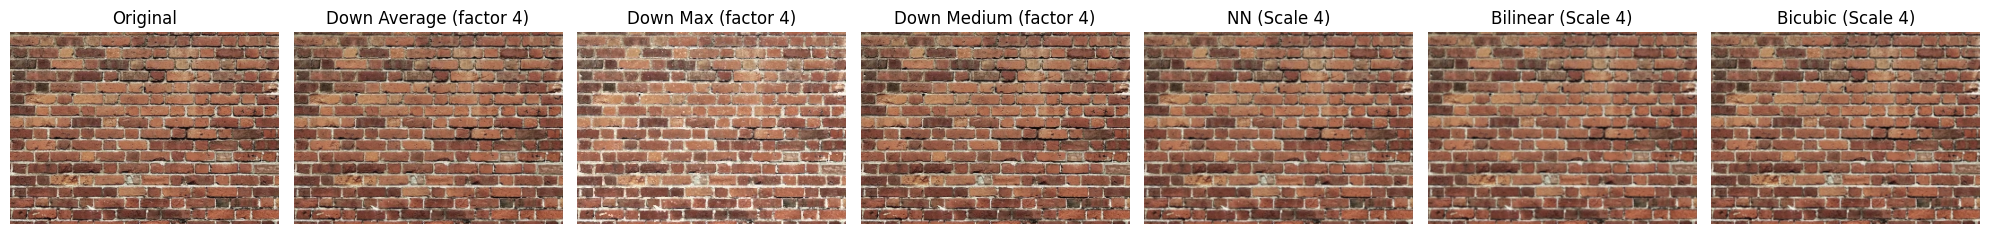

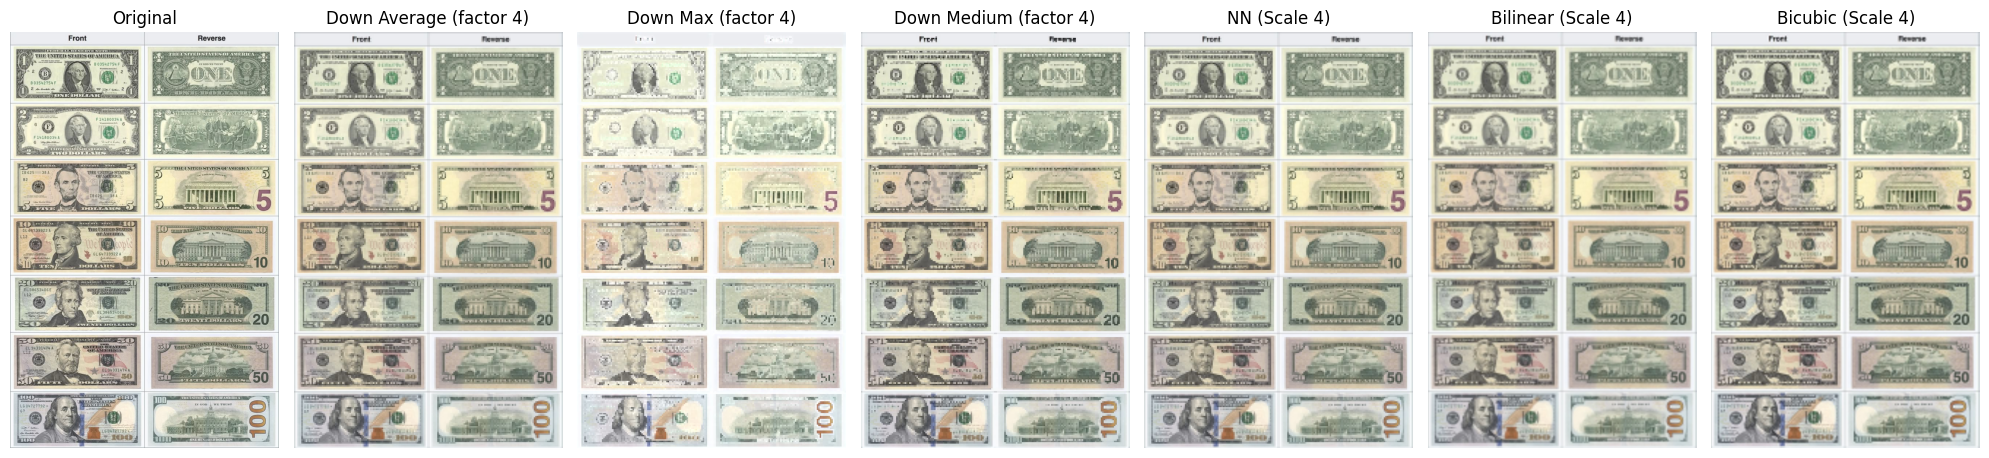

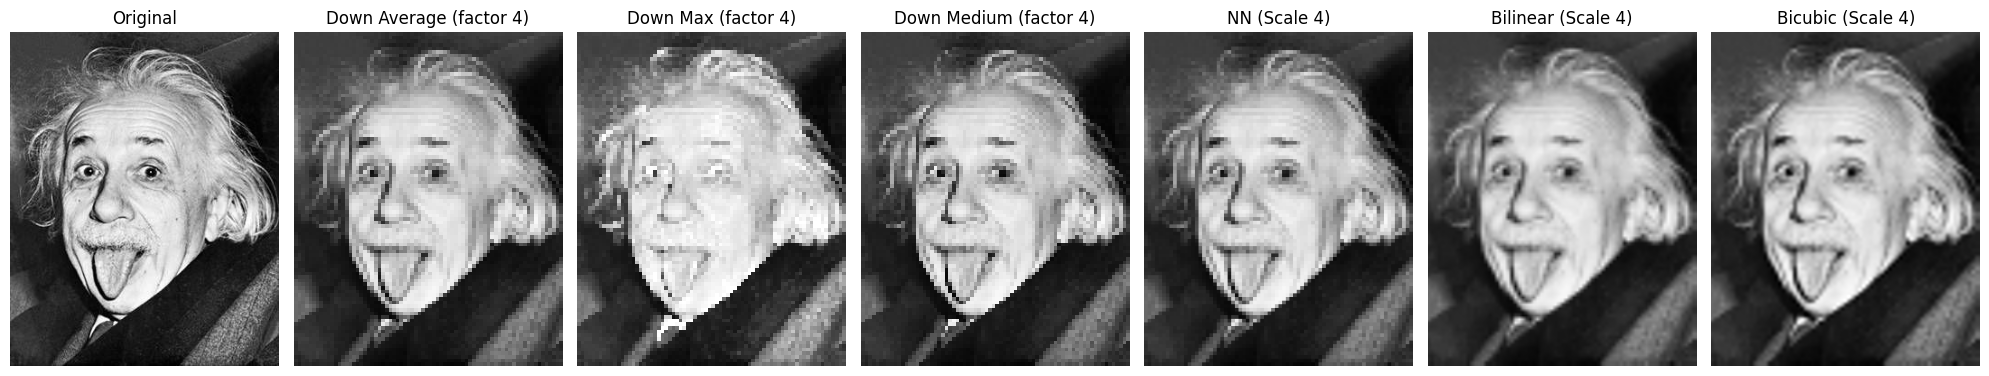

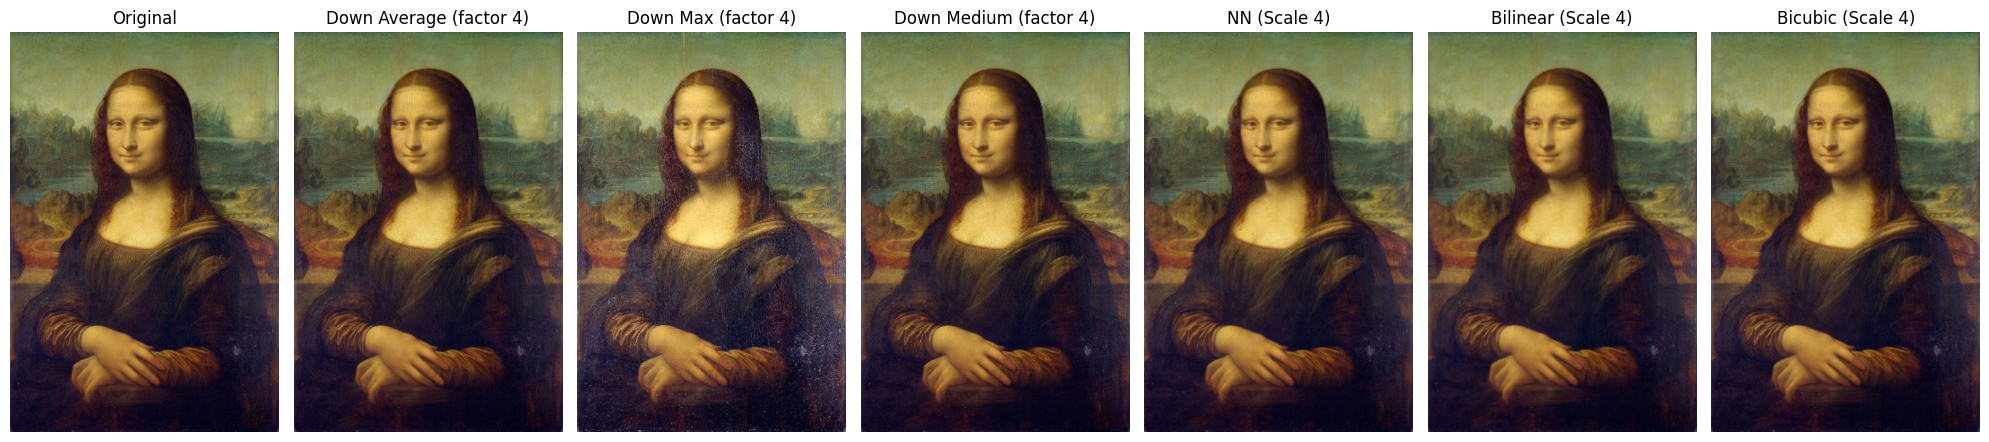

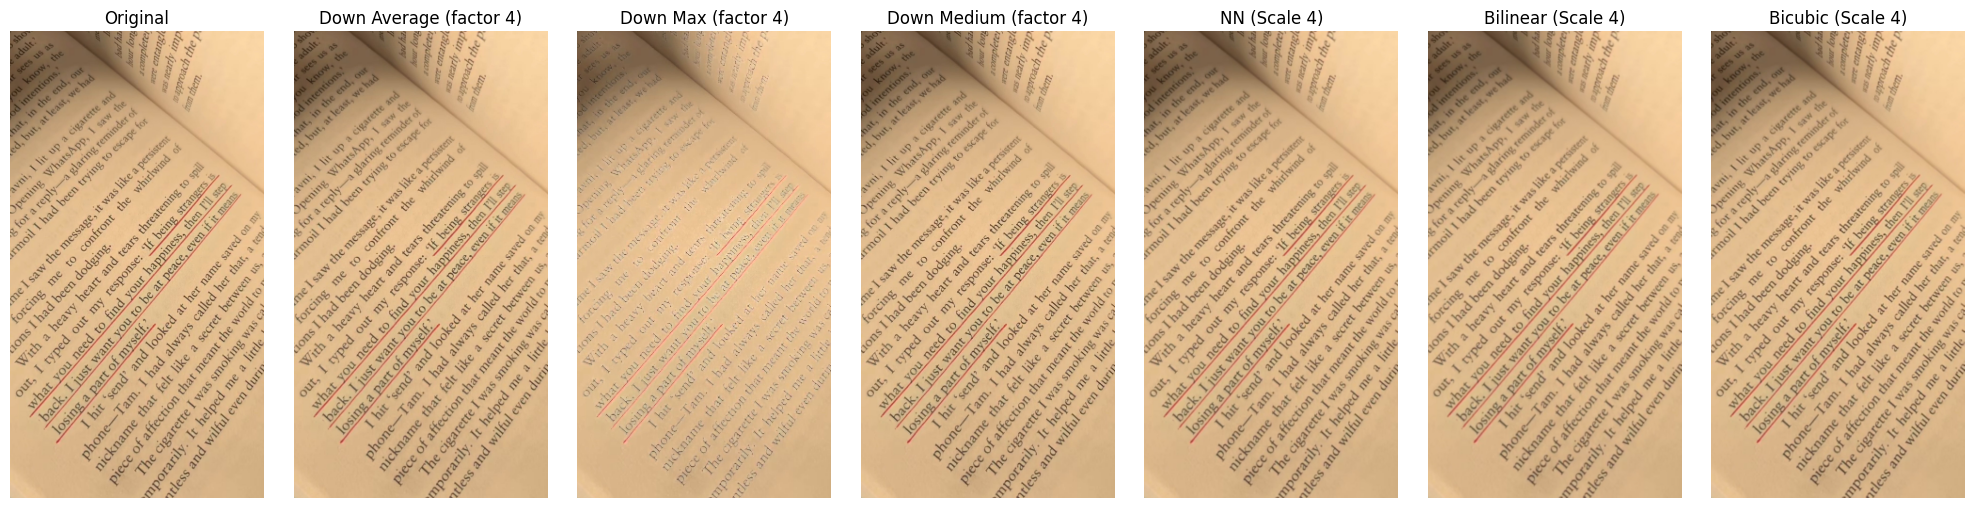

In [ ]:
image_folder = Path("Images")
image_files = [
    "Arsenal.jpg", 
    "Bricks.jpg", 
    "dollars.jpg", 
    "Einstein.jpg", 
    "Mona Lisa.jpg", 
    "Page.jpg"
]
for file_name in image_files:
    img_path = image_folder / file_name
    
    img_pil = Image.open(img_path).convert("RGB")
    img_array = np.array(img_pil)
    
    img_down_avg = downsampling(img_array, factor=5, method='average')
    img_down_max = downsampling(img_array, factor=5, method='max')
    img_down_medium = downsampling(img_array, factor=5, method='medium')
    
    img_up_nn = UpSamplingNN(img_down_avg, scale=5)
    img_up_bilinear = UpSamplingBilinear(img_down_avg, scale=5)
    img_up_bicubic = UpSamplingBicubic(img_down_avg, scale=5)
    
    fig, axes = plt.subplots(1, 7, figsize=(20, 5))
    axes[0].imshow(img_array); axes[0].set_title("Original")
    axes[1].imshow(img_down_avg); axes[1].set_title("Down Average (factor 5)")
    axes[2].imshow(img_down_max); axes[2].set_title("Down Max (factor 5)")
    axes[3].imshow(img_down_medium); axes[3].set_title("Down Medium (factor 5)")
    axes[4].imshow(img_up_nn); axes[4].set_title("NN (Scale 5)")
    axes[5].imshow(img_up_bilinear); axes[5].set_title("Bilinear (Scale 5)")
    axes[6].imshow(img_up_bicubic); axes[6].set_title("Bicubic (Scale 5)")
    
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()